# Cetacean Detection — Model vs Expert Comparison (ARBAS, **5-second clip level**)

Compares model predictions against expert annotations, evaluating at the
**5-second clip** resolution (not collapsed to WAV/interval level).

- **Expert format**: two XLSX sheets (May / August) with PAMGuard vote counts per
  1-min WAV for **multiple species**. All 1-min WAVs are aggregated to 5-min intervals;
  an interval is expert-positive if any WAV in it has total votes > 0.
  Model-only intervals (no expert annotation at all) are treated as **negatives** and
  kept in the evaluation.
- **Multi-species**: expert annotated Dd, Gg, Gm, Oo, Pm, Sc, Tt, Ambig + expert-only
  species (Bb, Dc, Lo, Zc) not in the model vocabulary. Headline evaluation is
  **cetacean-in-general**; per-species breakdown is in cell D.
- **Join key**: 5-min interval floored from `YYMMDDHHMMSS` WAV timestamp (same as
  Harrapatu).

### Five decoding variants (same MLP logits, different post-hoc decoding)
| Variant | How it decides the clip label |
|---|---|
| `argmax`     | plain softmax argmax |
| `vec`        | per-class `w·logit + b`, inv-freq weighted |
| `pr`         | argmax among species clearing F1-optimal threshold, else background |
| `consensus3` | all three (argmax/vec/pr) agree → that label, else `uncertain` |
| `consensus2` | ≥2 of the three agree on a label → that label, else `uncertain` |

For each variant a clip is a **detection** if its label is not `background` /
`uncertain`. `uncertain` is treated as non-detection.

### TP / FP / TN / FN definition
The unit counted is the **5-second clip**, but TP vs FN is gated at the
interval (5-min) level, because an expert "positive" label on a 5-min interval does
**not** mean signal is present in every 5-second window:

**Expert-positive interval** (any 1-min WAV in the interval had votes > 0)
- if **≥1 clip fires** → interval is *caught*. Firing clips → **TP**,
  non-firing clips → **TN**.
- if **0 clips fire** → interval is *missed*. Every clip → **FN**.

**Expert-negative interval** (all votes zero, or model-only interval)
- firing clip → **FP**
- non-firing clip → **TN**

All five variants are evaluated independently under this same rule.

In [1]:
# ── 0. Imports & paths ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── EDIT THESE ───────────────────────────────────────────────────────────────
MY_PREDICTIONS_CSV = r"/data2/mromaniuc/cet-det/inference/inference_arbas/predictions/arbas_predictions_l4.csv"
EXPERT_MAY_XLSX    = r"/data2/mromaniuc/cet-det/inference/inference_arbas/comparison/expert_validated_data/XIULOS_MAIG_TOTAL.xlsx"
EXPERT_AUG_XLSX    = r"/data2/mromaniuc/cet-det/inference/inference_arbas/comparison/expert_validated_data/XiulosAGOST_TOTAL.xlsx"
SPECTROGRAM_DIR    = r"/data2/mromaniuc/cet-det/inference/inference_arbas/spectrograms/spectrograms"
OUTPUT_CSV         = "arbas_comparison_5sec_v1.csv"           # per-variant clip-level summary
SEGMENT_OUTPUT_CSV = "arbas_comparison_5sec_v1_segments.csv"  # per-clip inspector

EXPERT_MAY_SHEET = 'in'
EXPERT_AUG_SHEET = 'XiulosAGOST_TOTAL'
# ─────────────────────────────────────────────────────────────────────────────

# The five decoding variants evaluated throughout the notebook.
VARIANTS = ['argmax', 'vec', 'pr', 'consensus3', 'consensus2']

def normalise_wav_name(x):
    """Return just 'XXXX.wav' from any path, Windows or POSIX, with cleanup."""
    if pd.isna(x):
        return None
    s = str(x).strip().strip('"').strip("'")
    s = s.replace('\\\\', '/').replace('\\', '/')
    s = s.split('/')[-1]
    s = s.strip().lower()
    if not s.endswith('.wav'):
        s = s + '.wav'
    return s

def interval_from_wav(wav_name):
    """Extract YYMMDDHHMMSS timestamp and floor to nearest 5-min interval.

    '6338.240528160459.wav' -> '240528160000'  (floor to HH MM00, nearest 5 min)
    Works on raw paths too (normalise_wav_name applied first).
    """
    if pd.isna(wav_name):
        return None
    base = normalise_wav_name(wav_name)
    parts = base.split('.')
    if len(parts) < 2:
        return None
    ts = parts[1]   # YYMMDDHHMMSS, 12 chars
    if len(ts) != 12 or not ts.isdigit():
        return None
    mm = int(ts[8:10])
    mm5 = (mm // 5) * 5
    return ts[:8] + f"{mm5:02d}" + "00"

print("Config loaded.  Self-test of interval_from_wav:")
for t in [r'D:\\IM-23-ARBAS\\Soundtrap 6338\\6338.240528160459.wav',
          '6338.240528160459.wav', '6312.240806141558.wav',
          '6338.240528160000.wav']:
    print(f"  {t!r:70s} -> {interval_from_wav(t)!r}")

Config loaded.  Self-test of interval_from_wav:
  'D:\\\\IM-23-ARBAS\\\\Soundtrap 6338\\\\6338.240528160459.wav'         -> '240528160000'
  '6338.240528160459.wav'                                                -> '240528160000'
  '6312.240806141558.wav'                                                -> '240806141500'
  '6338.240528160000.wav'                                                -> '240528160000'


In [2]:
# ── 1. Load model predictions & build the five variant labels ─────────────────
df_mine = pd.read_csv(MY_PREDICTIONS_CSV)
print(f"Raw CSV: {len(df_mine):,} rows, {df_mine.shape[1]} columns")

PATH_COL = next((c for c in ['wav_path', 'wav_name', 'file', 'filename', 'path']
                 if c in df_mine.columns), None)
assert PATH_COL is not None, f"No path column found. Columns: {list(df_mine.columns)}"
print(f"Using '{PATH_COL}' as the wav path column.")

df_mine['wav_name'] = df_mine[PATH_COL].apply(normalise_wav_name)
df_mine['interval'] = df_mine['wav_name'].map(interval_from_wav)
print(f"Example wav_name: {df_mine['wav_name'].iloc[0]!r}  interval: {df_mine['interval'].iloc[0]!r}")

# Rename prob columns to short codes
PROB_RENAME = {
    'prob_Balaenoptera_acutorostrata': 'prob_Ba',
    'prob_Balaenoptera_physalus':      'prob_Bp',
    'prob_Delphinidae_unknown':        'prob_Ambig',
    'prob_Delphinus_delphis':          'prob_Dd',
    'prob_Globicephala_melas':         'prob_Gm',
    'prob_Grampus_griseus':            'prob_Gg',
    'prob_Orcinus_orca':               'prob_Oo',
    'prob_Physeter_macrocephalus':     'prob_Pm',
    'prob_Stenella_coeruleoalba':      'prob_Sc',
    'prob_Tursiops_truncatus':         'prob_Tt',
    'prob_background':                 'prob_bg',
}
df_mine.rename(columns=PROB_RENAME, inplace=True)

CETACEAN_PROB_COLS = ['prob_Ba','prob_Bp','prob_Ambig','prob_Dd','prob_Gm',
                      'prob_Gg','prob_Oo','prob_Pm','prob_Sc','prob_Tt']
missing_probs = [c for c in CETACEAN_PROB_COLS + ['prob_bg'] if c not in df_mine.columns]
assert not missing_probs, f"Missing probability columns after rename: {missing_probs}"

BASE_STRATS = ['pred_argmax', 'pred_vec', 'pred_pr']
for col in BASE_STRATS:
    assert col in df_mine.columns, f"Strategy column '{col}' not in CSV."
    df_mine[col] = df_mine[col].astype(str).str.strip()

# Guard against duplicate (wav_name, segment_index)
if 'segment_index' in df_mine.columns:
    seg_dups = df_mine.duplicated(subset=['wav_name', 'segment_index']).sum()
    if seg_dups:
        print(f"  ⚠ {seg_dups} duplicate (wav_name, segment_index) — keeping first.")
        df_mine = df_mine.drop_duplicates(subset=['wav_name', 'segment_index'],
                                          keep='first').reset_index(drop=True)

# ── Build the two consensus labels per clip ───────────────────────────────────
# consensus3: all three agree -> that label, else 'uncertain'
# consensus2: any label held by >=2 of the three -> that label, else 'uncertain'
import collections

def consensus_labels(row):
    votes = [row['pred_argmax'], row['pred_vec'], row['pred_pr']]
    counts = collections.Counter(votes)
    label, n = counts.most_common(1)[0]
    cons3 = label if n == 3 else 'uncertain'
    cons2 = label if n >= 2 else 'uncertain'
    return pd.Series({'pred_consensus3': cons3, 'pred_consensus2': cons2})

df_mine[['pred_consensus3', 'pred_consensus2']] = df_mine.apply(consensus_labels, axis=1)

# Detection flag per variant: fires if label is a real cetacean species
NON_DETECTION = {'background', 'uncertain'}
for v in VARIANTS:
    df_mine[f'fired_{v}'] = ~df_mine[f'pred_{v}'].isin(NON_DETECTION)

df_mine['max_cetacean_prob'] = df_mine[CETACEAN_PROB_COLS].max(axis=1)

print(f"\nLoaded {len(df_mine):,} clips from {df_mine['wav_name'].nunique():,} WAV files "
      f"across {df_mine['interval'].nunique():,} unique 5-min intervals")
print("\nClip-level firing rate per variant:")
for v in VARIANTS:
    n = int(df_mine[f'fired_{v}'].sum())
    print(f"  {v:11s}: {n:,} firing clips ({100*n/len(df_mine):.1f}%)")
for v in ['consensus3', 'consensus2']:
    n_unc = int((df_mine[f'pred_{v}'] == 'uncertain').sum())
    print(f"  {v:11s}: {n_unc:,} 'uncertain' clips")

df_mine[['wav_name','interval','segment_index','offset_s',
         'pred_argmax','pred_vec','pred_pr','pred_consensus3','pred_consensus2']].head(5)

Raw CSV: 117,650 rows, 23 columns
Using 'wav_path' as the wav path column.
Example wav_name: '6338.240528160459.wav'  interval: '240528160000'

Loaded 117,650 clips from 9,805 WAV files across 1,963 unique 5-min intervals

Clip-level firing rate per variant:
  argmax     : 37,916 firing clips (32.2%)
  vec        : 57,351 firing clips (48.7%)
  pr         : 18,349 firing clips (15.6%)
  consensus3 : 18,348 firing clips (15.6%)
  consensus2 : 33,442 firing clips (28.4%)
  consensus3 : 39,189 'uncertain' clips
  consensus2 : 4,288 'uncertain' clips


,wav_name,interval,segment_index,offset_s,pred_argmax,pred_vec,pred_pr,pred_consensus3,pred_consensus2
0,6338.240528160459.wav,240528160000,0,0.0,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown
1,6338.240528160459.wav,240528160000,1,5.0,Delphinidae_unknown,Delphinidae_unknown,background,uncertain,Delphinidae_unknown
2,6338.240528160459.wav,240528160000,2,10.0,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown
3,6338.240528160459.wav,240528160000,3,15.0,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown
4,6338.240528160459.wav,240528160000,4,20.0,background,Delphinidae_unknown,background,uncertain,background


In [3]:
# ── 2. Load expert annotations ───────────────────────────────────────────────
# Two XLSX sheets (May / August) with PAMGuard vote counts per 1-min WAV.
# We aggregate votes to 5-min interval level (any WAV positive -> interval positive).

EXPERT_VOTE_RENAME = {
    'Ambig_votes': 'exp_Ambig',
    'Bb_votes':    'exp_Bb',   # expert-only species (not in model vocab)
    'Dc_votes':    'exp_Dc',
    'Dd_votes':    'exp_Dd',
    'Gg_votes':    'exp_Gg',
    'Gm_votes':    'exp_Gm',
    'Lo_votes':    'exp_Lo',
    'Oo_votes':    'exp_Oo',
    'Pm_votes':    'exp_Pm',
    'Sc_votes':    'exp_Sc',
    'Tt_votes':    'exp_Tt',
    'Zc_votes':    'exp_Zc',
}
EXP_VOTE_COLS = list(EXPERT_VOTE_RENAME.values())

# PAMGuard vote cells may be inflated by power-of-10 locale artefact — recover them.
VOTE_MAX = 10.0

def recover_vote(x):
    if pd.isna(x):
        return 0.0
    try:
        f = float(str(x).strip().strip('"').strip("'").replace(',', '.'))
    except (ValueError, TypeError):
        return 0.0
    if f == 0.0:
        return 0.0
    sign = -1.0 if f < 0 else 1.0
    f = abs(f)
    while f >= VOTE_MAX:
        f /= 10.0
    return sign * f

def clean_vote_series(s):
    raw = pd.to_numeric(s.astype(str).str.strip().str.replace(',', '.', regex=False),
                        errors='coerce')
    n_inflated = int((raw.abs() >= VOTE_MAX).sum())
    out = s.apply(recover_vote)
    return out, n_inflated

def load_expert_sheet(path, sheet_name):
    df = pd.read_excel(path, sheet_name=sheet_name)
    df.columns = [str(c).strip() for c in df.columns]

    fname_col = next((c for c in df.columns
                      if c.strip().upper() in ('ARXIU', 'FILENAME', 'WAV', 'FILE')), None)
    if fname_col is None:
        raise ValueError(f"No filename column in {Path(path).name}/{sheet_name}. "
                         f"Columns: {list(df.columns)}")
    df.rename(columns={fname_col: 'wav_name_raw'}, inplace=True)
    df['wav_name'] = df['wav_name_raw'].apply(normalise_wav_name)
    df['interval'] = df['wav_name'].map(interval_from_wav)

    df.rename(columns=EXPERT_VOTE_RENAME, inplace=True)
    audit = {}
    for col in EXP_VOTE_COLS:
        if col in df.columns:
            df[col], n_inflated = clean_vote_series(df[col])
            if n_inflated:
                audit[col] = n_inflated
        else:
            df[col] = 0.0

    if audit:
        total = sum(audit.values())
        print(f"  {Path(path).name}: recovered {total} inflated vote cell(s): " +
              ", ".join(f"{k.replace('exp_','')}={v}" for k, v in sorted(audit.items())))

    df['source'] = Path(path).stem
    df = df[df['wav_name'].notna() & df['interval'].notna()].copy()
    df['exp_cetacean_detected'] = df[EXP_VOTE_COLS].sum(axis=1) > 0

    vote_mat = df[EXP_VOTE_COLS]
    row_max = vote_mat.max(axis=1)
    n_ties = ((vote_mat.eq(row_max, axis=0).sum(axis=1) > 1)
              & df['exp_cetacean_detected']).sum()
    if n_ties:
        print(f"  ⚠ {Path(path).name}/{sheet_name}: {n_ties} row(s) have a top-species tie.")

    df['exp_top_species'] = vote_mat.idxmax(axis=1).str.replace('exp_', '')
    df.loc[~df['exp_cetacean_detected'], 'exp_top_species'] = 'background'
    return df

df_exp_may = load_expert_sheet(EXPERT_MAY_XLSX, EXPERT_MAY_SHEET)
df_exp_aug = load_expert_sheet(EXPERT_AUG_XLSX, EXPERT_AUG_SHEET)

print(f"\nMay   : {len(df_exp_may):,} WAVs  ({df_exp_may['exp_cetacean_detected'].sum()} cetacean)")
print(f"August: {len(df_exp_aug):,} WAVs  ({df_exp_aug['exp_cetacean_detected'].sum()} cetacean)")

df_exp_all = pd.concat([df_exp_may, df_exp_aug], ignore_index=True)
dups = df_exp_all['wav_name'].duplicated().sum()
if dups:
    print(f"  ⚠ {dups} duplicate wav_name(s) across sheets — keeping first.")
    df_exp_all = df_exp_all.drop_duplicates(subset='wav_name', keep='first')

# ── Aggregate WAV-level expert votes → 5-min interval level ──────────────────
# An interval is expert-positive if ANY 1-min WAV in it had votes > 0.
# Vote sums carry through for the per-species breakdown in cell D.
def agg_expert_interval(grp):
    exp_pos = grp['exp_cetacean_detected'].any()
    vote_sum = grp[EXP_VOTE_COLS].sum()
    top_sp = vote_sum.idxmax().replace('exp_', '') if exp_pos else 'background'
    return pd.Series({
        'exp_positive':     exp_pos,
        'exp_top_species':  top_sp,
        'n_wavs_annotated': len(grp),
        'source':           ', '.join(sorted(grp['source'].unique())),
        **{f'sum_{c}': vote_sum[c] for c in EXP_VOTE_COLS},
    })

df_expert = (
    df_exp_all.groupby('interval', sort=False)
    .apply(agg_expert_interval, include_groups=False)
    .reset_index()
)
print(f"\nUnique expert-annotated 5-min intervals: {len(df_expert):,}")
print(f"  Expert-positive: {df_expert['exp_positive'].sum():,}")
print(f"  Expert-negative: {(~df_expert['exp_positive']).sum():,}")
df_expert[['interval','exp_positive','exp_top_species','n_wavs_annotated','source']].head()

  XIULOS_MAIG_TOTAL.xlsx: recovered 191 inflated vote cell(s): Dc=35, Dd=26, Gg=75, Lo=7, Oo=1, Sc=13, Tt=34
  XiulosAGOST_TOTAL.xlsx: recovered 2545 inflated vote cell(s): Dc=412, Dd=196, Gg=933, Lo=46, Oo=8, Sc=255, Tt=695
  ⚠ XiulosAGOST_TOTAL.xlsx/XiulosAGOST_TOTAL: 2 row(s) have a top-species tie.

May   : 4,062 WAVs  (115 cetacean)
August: 4,005 WAVs  (1704 cetacean)

Unique expert-annotated 5-min intervals: 1,616
  Expert-positive: 542
  Expert-negative: 1,074


,interval,exp_positive,exp_top_species,n_wavs_annotated,source
0,240528160000,False,background,1,XIULOS_MAIG_TOTAL
1,240528160500,True,Gg,5,XIULOS_MAIG_TOTAL
2,240528161000,False,background,5,XIULOS_MAIG_TOTAL
3,240528161500,False,background,5,XIULOS_MAIG_TOTAL
4,240528162000,False,background,5,XIULOS_MAIG_TOTAL


In [4]:
# ── 2b. Key-overlap diagnostic ────────────────────────────────────────────────
mine_intervals    = set(df_mine['interval'].dropna().unique())
exp_intervals     = set(df_expert['interval'].dropna().unique())
exp_pos_intervals = set(df_expert.loc[df_expert['exp_positive'], 'interval'].dropna().unique())

overlap     = mine_intervals & exp_intervals
only_expert = exp_intervals  - mine_intervals
only_model  = mine_intervals - exp_intervals

print(f"Model intervals              : {len(mine_intervals):,}")
print(f"Expert-annotated intervals   : {len(exp_intervals):,}")
print(f"  Expert-positive            : {len(exp_pos_intervals):,}")
print(f"  Expert-negative            : {len(exp_intervals) - len(exp_pos_intervals):,}")
print(f"Overlap (model saw + expert annotated): {len(overlap):,}")
print(f"Expert-annotated NOT in model         : {len(only_expert):,}")
print(f"  → these cannot be evaluated (model never processed them)")
print(f"Model intervals with no expert annotation (treated as negatives): {len(only_model):,}")

if len(overlap) == 0:
    print("\n❌ ZERO OVERLAP — the merge will be empty. Inspect sample keys:")
    print("  model :", sorted(mine_intervals)[:3])
    print("  expert:", sorted(exp_intervals)[:3])
    print("  → check that interval_from_wav floors timestamps consistently.")
else:
    print(f"\n✓ Overlap looks good. Sample matched intervals: {sorted(overlap)[:3]}")

Model intervals              : 1,963
Expert-annotated intervals   : 1,616
  Expert-positive            : 542
  Expert-negative            : 1,074
Overlap (model saw + expert annotated): 1,616
Expert-annotated NOT in model         : 0
  → these cannot be evaluated (model never processed them)
Model intervals with no expert annotation (treated as negatives): 347

✓ Overlap looks good. Sample matched intervals: ['240528160000', '240528160500', '240528161000']


In [5]:
# ── 3. Attach expert label to every clip + interval-level caught sets ─────────
# Step 1: merge expert positivity flag onto every clip.
# Step 2: for each variant, determine which intervals are "caught" (≥1 clip fired).
#
# NOTE: model-only intervals (no expert annotation) are NEGATIVES and stay in.
# Expert-annotated intervals the model never processed are excluded automatically
# since they are absent from df_mine.

SP_LONG_TO_SHORT = {k.replace('prob_', ''): v.replace('prob_', '')
                    for k, v in PROB_RENAME.items()}

def to_short(lbl):
    lbl = str(lbl)
    return SP_LONG_TO_SHORT.get(lbl, lbl)   # 'uncertain'/'background' pass through

clips = df_mine.copy()

# Merge expert interval-level data onto every clip (left join keeps model-only intervals)
EXP_IVL_COLS = ['interval', 'exp_positive', 'exp_top_species', 'n_wavs_annotated', 'source']
EXP_IVL_COLS += [c for c in df_expert.columns if c.startswith('sum_')]
clips = clips.merge(
    df_expert[[c for c in EXP_IVL_COLS if c in df_expert.columns]],
    on='interval', how='left'
)
clips['exp_positive']   = clips['exp_positive'].fillna(False).astype(bool)
clips['exp_top_species'] = clips['exp_top_species'].fillna('no_label')
clips['exp_annotated']  = clips['interval'].isin(exp_intervals)

# For each variant: which intervals are "caught" = >=1 firing clip
caught = {}
for v in VARIANTS:
    fired_per_ivl = clips.groupby('interval')[f'fired_{v}'].any()
    caught[v] = set(fired_per_ivl[fired_per_ivl].index)

n_pos_clips = int(clips['exp_positive'].sum())
print(f"Clips total            : {len(clips):,}")
print(f"  in expert-positive intervals: {n_pos_clips:,}")
print(f"  in expert-negative intervals: {int((~clips['exp_positive']).sum()):,}")
print(f"Evaluable intervals    : {clips['interval'].nunique():,}")
print(f"  (expert-annotated NOT in model, excluded: {len(only_expert)})")

exp_pos_set = set(df_expert.loc[df_expert['exp_positive'], 'interval'])
n_exp_pos_ivl = clips[clips['exp_positive']]['interval'].nunique()
print("\nExpert-positive intervals caught (>=1 firing clip) per variant:")
for v in VARIANTS:
    caught_pos = len(caught[v] & exp_pos_set & mine_intervals)
    print(f"  {v:11s}: {caught_pos:,} / {n_exp_pos_ivl:,} positive intervals caught")

Clips total            : 117,650
  in expert-positive intervals: 32,520
  in expert-negative intervals: 85,130
Evaluable intervals    : 1,963
  (expert-annotated NOT in model, excluded: 0)

Expert-positive intervals caught (>=1 firing clip) per variant:
  argmax     : 519 / 542 positive intervals caught
  vec        : 540 / 542 positive intervals caught
  pr         : 274 / 542 positive intervals caught
  consensus3 : 274 / 542 positive intervals caught
  consensus2 : 494 / 542 positive intervals caught


In [6]:
# ── 4. Clip-level TP / FP / TN / FN for each variant ──────────────────────────
#
#   expert-positive interval:
#       caught (>=1 clip fired):  firing clip -> TP ; non-firing clip -> TN
#       missed (0 clips fired)  :  every clip -> FN
#   expert-negative interval (annotation=negative OR no annotation):
#       firing clip -> FP ; non-firing clip -> TN

def clip_outcomes(clips, fired_col, exp_pos_col, caught_intervals):
    """Return a Series of 'TP'/'FP'/'TN'/'FN' for every clip under one variant."""
    fired     = clips[fired_col].to_numpy()
    exp_pos   = clips[exp_pos_col].to_numpy()
    is_caught = clips['interval'].isin(caught_intervals).to_numpy()

    out = np.empty(len(clips), dtype=object)
    # expert-positive, interval caught
    m = exp_pos & is_caught
    out[m &  fired] = 'TP'
    out[m & ~fired] = 'TN'
    # expert-positive, interval missed
    m = exp_pos & ~is_caught
    out[m] = 'FN'
    # expert-negative (annotated-negative or unannotated model-only)
    m = ~exp_pos
    out[m &  fired] = 'FP'
    out[m & ~fired] = 'TN'
    return pd.Series(out, index=clips.index)

def metrics_from_counts(TP, FP, TN, FN):
    recall      = TP / (TP + FN) if (TP + FN) else float('nan')
    precision   = TP / (TP + FP) if (TP + FP) else float('nan')
    specificity = TN / (TN + FP) if (TN + FP) else float('nan')
    f1 = (2*precision*recall / (precision+recall)
          if (precision and recall
              and not np.isnan(precision) and not np.isnan(recall))
          else float('nan'))
    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP+TN+FP+FN) else float('nan')
    return recall, precision, specificity, f1, accuracy

rows = []
for v in VARIANTS:
    oc = clip_outcomes(clips, f'fired_{v}', 'exp_positive', caught[v])
    clips[f'outcome_{v}'] = oc
    c = oc.value_counts()
    TP = int(c.get('TP', 0)); FP = int(c.get('FP', 0))
    TN = int(c.get('TN', 0)); FN = int(c.get('FN', 0))
    rc, pr, sp, f1, acc = metrics_from_counts(TP, FP, TN, FN)
    rows.append({'variant': v, 'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN,
                 'recall': rc, 'precision': pr, 'specificity': sp,
                 'F1': f1, 'accuracy': acc})

clip_metrics = pd.DataFrame(rows).set_index('variant')

print("Clip-level (5-second) evaluation — all five variants\n")
print(clip_metrics.to_string(
    float_format=lambda x: f'{x:.3f}',
    formatters={'TP': '{:,}'.format, 'FP': '{:,}'.format,
                'TN': '{:,}'.format, 'FN': '{:,}'.format}))

clip_metrics.reset_index().to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved per-variant clip-level summary → {OUTPUT_CSV}")

Clip-level (5-second) evaluation — all five variants

               TP     FP     TN     FN  recall  precision  specificity    F1  accuracy
variant                                                                               
argmax      7,938 29,978 78,354  1,380   0.852      0.209        0.723 0.336     0.733
vec        15,266 42,085 60,179    120   0.992      0.266        0.588 0.420     0.641
pr          2,045 16,304 83,221 16,080   0.113      0.111        0.836 0.112     0.725
consensus3  2,044 16,304 83,222 16,080   0.113      0.111        0.836 0.112     0.725
consensus2  5,981 27,461 81,328  2,880   0.675      0.179        0.748 0.283     0.742

Saved per-variant clip-level summary → arbas_comparison_5sec_v1.csv


In [7]:
# ── 5. Save per-clip inspector CSV ────────────────────────────────────────────
# One row per 5-second clip. Columns: labels + fired flags + outcomes for all
# five variants, probabilities, and expert metadata.
seg = clips.copy()
seg['exp_cetacean_detected'] = seg['exp_positive']

# Short-code the labels for readability in the inspector
for v in VARIANTS:
    seg[f'pred_{v}'] = seg[f'pred_{v}'].map(to_short)

SEG_COLS = (
    ['wav_name', 'interval', 'segment_index', 'offset_s']
    + [f'pred_{v}' for v in VARIANTS]
    + [f'fired_{v}' for v in VARIANTS]
    + [f'outcome_{v}' for v in VARIANTS]
    + CETACEAN_PROB_COLS + ['prob_bg', 'max_cetacean_prob']
    + ['exp_positive', 'exp_cetacean_detected', 'exp_top_species', 'exp_annotated']
    + ['source']
)
SEG_COLS = [c for c in SEG_COLS if c in seg.columns]
seg[SEG_COLS].to_csv(SEGMENT_OUTPUT_CSV, index=False)

print(f"Saved per-clip inspector CSV → {SEGMENT_OUTPUT_CSV}")
print(f"  {len(seg):,} clips, {seg['interval'].nunique():,} intervals")
print("\nClip-outcome distribution per variant:")
for v in VARIANTS:
    print(f"  {v:11s}: {seg[f'outcome_{v}'].value_counts().to_dict()}")
seg[SEG_COLS].head(3)

Saved per-clip inspector CSV → arbas_comparison_5sec_v1_segments.csv
  117,650 clips, 1,963 intervals

Clip-outcome distribution per variant:
  argmax     : {'TN': 78354, 'FP': 29978, 'TP': 7938, 'FN': 1380}
  vec        : {'TN': 60179, 'FP': 42085, 'TP': 15266, 'FN': 120}
  pr         : {'TN': 83221, 'FP': 16304, 'FN': 16080, 'TP': 2045}
  consensus3 : {'TN': 83222, 'FP': 16304, 'FN': 16080, 'TP': 2044}
  consensus2 : {'TN': 81328, 'FP': 27461, 'TP': 5981, 'FN': 2880}


,wav_name,interval,segment_index,offset_s,pred_argmax,pred_vec,pred_pr,pred_consensus3,pred_consensus2,fired_argmax,...,prob_Pm,prob_Sc,prob_Tt,prob_bg,max_cetacean_prob,exp_positive,exp_cetacean_detected,exp_top_species,exp_annotated,source
0,6338.240528160459.wav,240528160000,0,0.0,Ambig,Ambig,Ambig,Ambig,Ambig,True,...,3.197167e-07,9.444356e-08,0.000035,0.000574,0.999385,False,False,background,True,XIULOS_MAIG_TOTAL
1,6338.240528160459.wav,240528160000,1,5.0,Ambig,Ambig,bg,uncertain,Ambig,True,...,2.087344e-06,6.836192e-06,0.024254,0.180867,0.793956,False,False,background,True,XIULOS_MAIG_TOTAL
2,6338.240528160459.wav,240528160000,2,10.0,Ambig,Ambig,Ambig,Ambig,Ambig,True,...,2.731829e-06,1.231625e-06,0.000448,0.024110,0.975346,False,False,background,True,XIULOS_MAIG_TOTAL


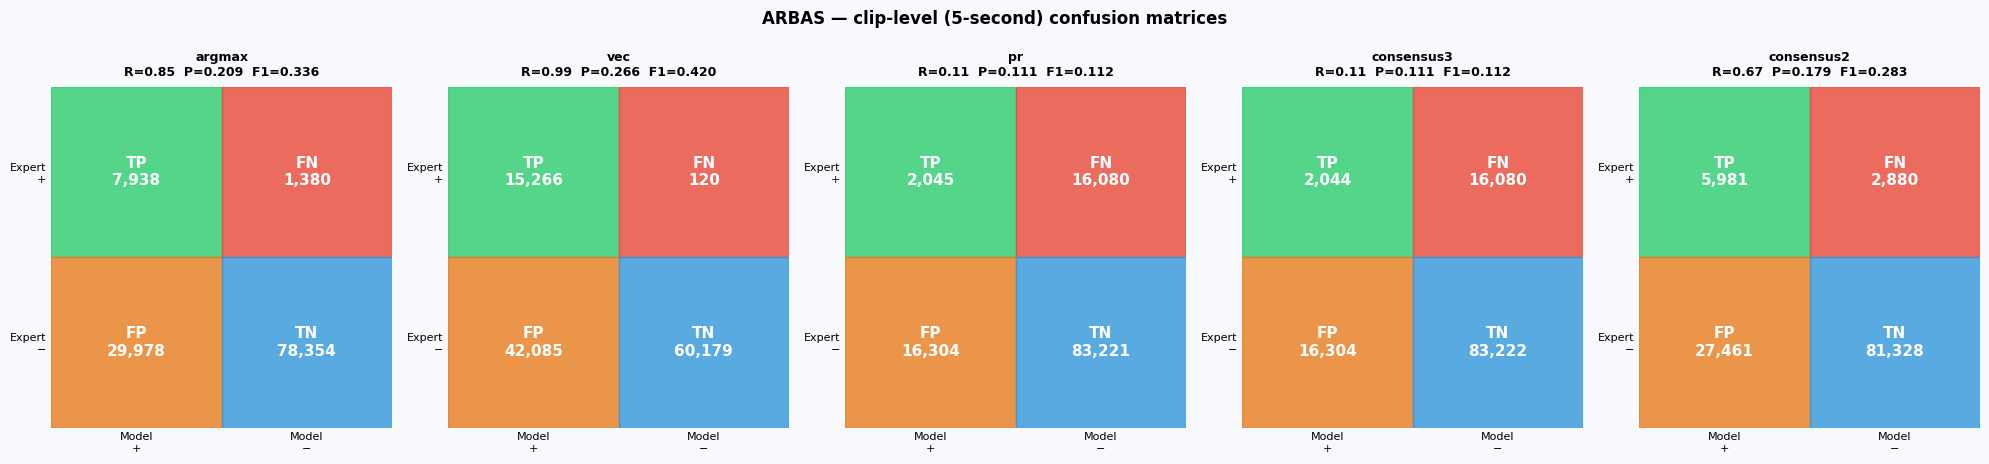

In [8]:
# ── B. Confusion matrices for all five variants ───────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(VARIANTS), figsize=(4*len(VARIANTS), 4.2))
fig.patch.set_facecolor('#f7f9fc')

for ax, v in zip(axes, VARIANTS):
    r = clip_metrics.loc[v]
    TP, FN, FP, TN = int(r['TP']), int(r['FN']), int(r['FP']), int(r['TN'])
    labels = [['TP', 'FN'], ['FP', 'TN']]
    counts = [[TP, FN], [FP, TN]]
    colors = [['#2ecc71', '#e74c3c'], ['#e67e22', '#3498db']]
    ax.set_xlim(0, 2); ax.set_ylim(0, 2); ax.set_aspect('equal')
    for rr in range(2):
        for cc in range(2):
            ax.add_patch(plt.Rectangle([cc, 1-rr], 1, 1, color=colors[rr][cc], alpha=0.82))
            ax.text(cc+0.5, 1.5-rr, f"{labels[rr][cc]}\n{counts[rr][cc]:,}",
                    ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    ax.set_xticks([0.5, 1.5]); ax.set_yticks([0.5, 1.5])
    ax.set_xticklabels(['Model\n+', 'Model\n−'], fontsize=8)
    ax.set_yticklabels(['Expert\n−', 'Expert\n+'], fontsize=8)
    ax.set_title(f"{v}\nR={r['recall']:.2f}  P={r['precision']:.3f}  F1={r['F1']:.3f}",
                 fontsize=9, fontweight='bold', pad=8)
    ax.tick_params(length=0)
    for spine in ax.spines.values(): spine.set_visible(False)

plt.suptitle('ARBAS — clip-level (5-second) confusion matrices',
             fontsize=12, y=1.04, fontweight='bold')
plt.tight_layout()
plt.show()

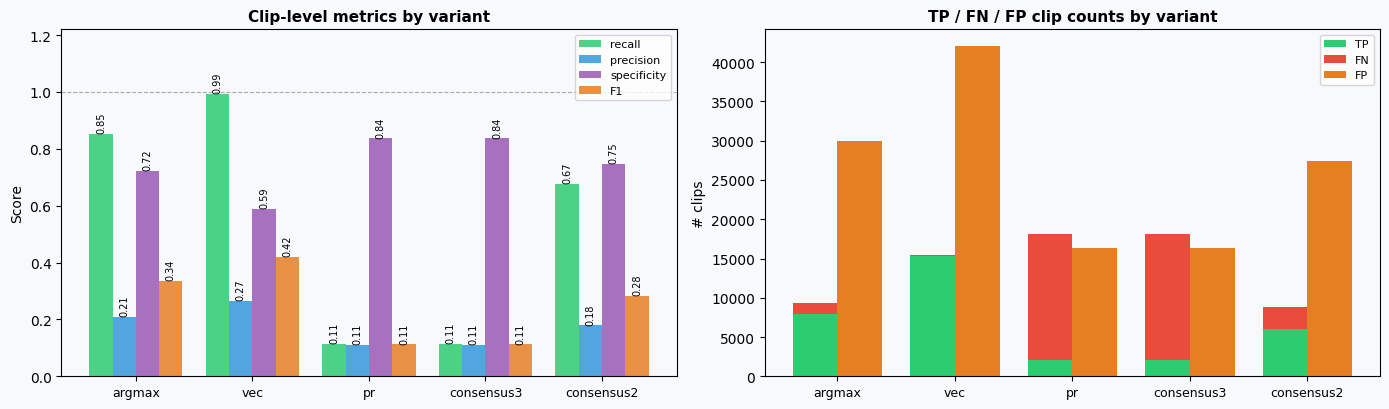

In [9]:
# ── C. Metric comparison across the five variants ─────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

cm = clip_metrics.reset_index()
x = np.arange(len(cm)); w = 0.2

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
fig.patch.set_facecolor('#f7f9fc')

ax = axes[0]
for i, (metric, color) in enumerate([('recall','#2ecc71'), ('precision','#3498db'),
                                      ('specificity','#9b59b6'), ('F1','#e67e22')]):
    bars = ax.bar(x + i*w, cm[metric].fillna(0), w, label=metric, color=color, alpha=0.85)
    for bar, val in zip(bars, cm[metric]):
        if not np.isnan(val):
            ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.2f}',
                    ha='center', fontsize=7, rotation=90)
ax.set_xticks(x + w*1.5); ax.set_xticklabels(cm['variant'], fontsize=9)
ax.set_ylim(0, 1.22); ax.set_ylabel('Score', fontsize=10)
ax.set_title('Clip-level metrics by variant', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.axhline(1.0, ls='--', lw=0.8, color='#aaa')
ax.set_facecolor('#f7f9fc')

ax = axes[1]
w2 = 0.38
ax.bar(x - w2/2, cm['TP'], w2, label='TP', color='#2ecc71')
ax.bar(x - w2/2, cm['FN'], w2, bottom=cm['TP'], label='FN', color='#e74c3c')
ax.bar(x + w2/2, cm['FP'], w2, label='FP', color='#e67e22')
ax.set_xticks(x); ax.set_xticklabels(cm['variant'], fontsize=9)
ax.set_ylabel('# clips', fontsize=10)
ax.set_title('TP / FN / FP clip counts by variant', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.set_facecolor('#f7f9fc')

plt.tight_layout(); plt.show()

## D. Per-species breakdown

Unlike Harrapatu, the ARBAS expert annotated **multiple species** (Dd, Gg, Gm, Oo, Pm, Sc, Tt, Ambig).
Expert-only species (Bb, Dc, Lo, Zc) are not in the model vocabulary — any interval
where the expert assigned those is an automatic FN at the species level.

The breakdown below works at **interval level** (whether any clip in the interval fired
that species label), matching the spirit of the clip-level TP rule.
Change `V` to switch the operating variant.

Per-species interval-level breakdown  (variant: argmax):
species  exp_intervals  model_maj  model_any  overlap_any  overlap_maj  only_expert  only_model_maj  recall_any  recall_maj
     Gg            441          0         24            9            0          432               0       0.020         0.0
     Tt             75         11        968           40            0           35              11       0.533         0.0
     Sc              7          0         23            0            0            7               0       0.000         0.0
     Dd              2          1        190            0            0            2               1       0.000         0.0
     Oo              0          0        371            0            0            0               0         NaN         NaN
     Gm              0          0         38            0            0            0               0         NaN         NaN
     Pm              0          0        315            0            0     

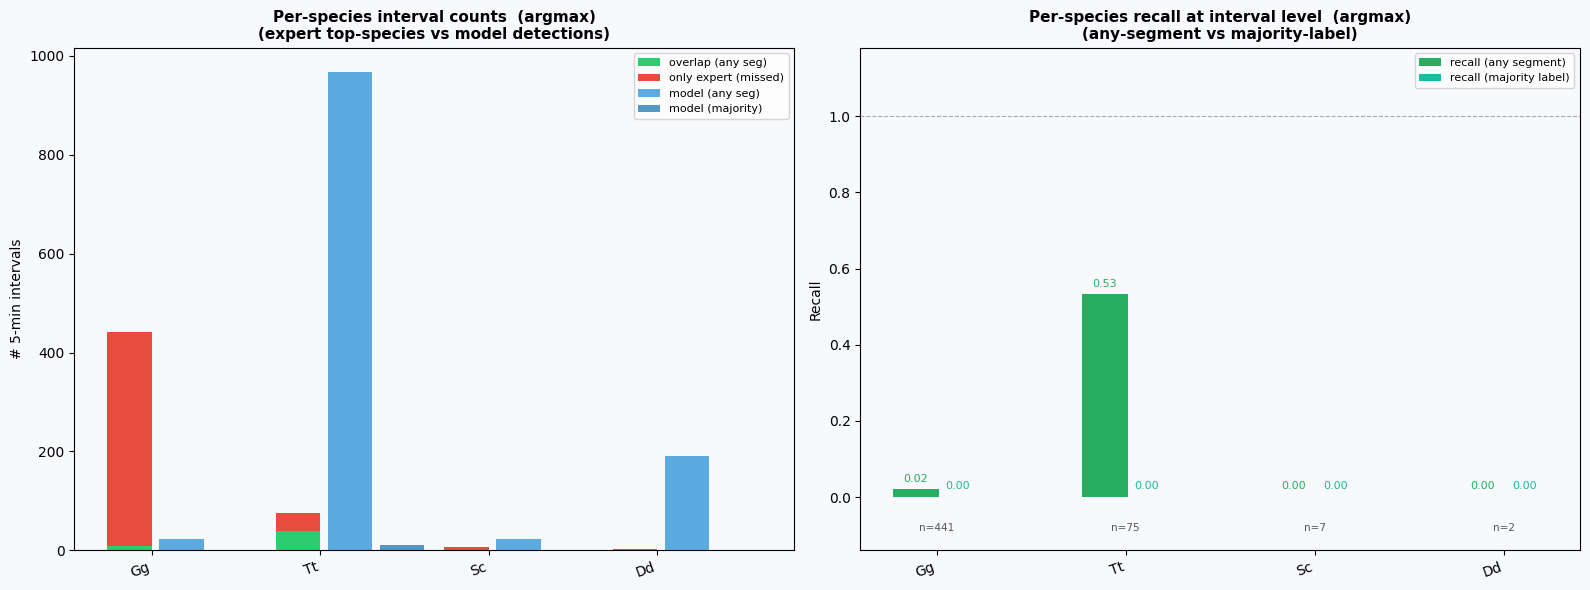

In [10]:
# ── D. Per-species breakdown ──────────────────────────────────────────────────
import matplotlib.pyplot as plt

V = 'argmax'   # ← pick any of: argmax, vec, pr, consensus3, consensus2

SHARED_SPECIES = ['Dd', 'Gg', 'Gm', 'Oo', 'Pm', 'Sc', 'Tt', 'Ambig']
# Expert-only species (Bb, Dc, Lo, Zc) not in model vocab → automatic FN if present

# Build interval-level species presence from clip predictions under variant V
# For each interval: which species labels fired at least once (any_set),
# and which was the plurality label (majority).
clip_lbl = clips[f'pred_{V}'].map(to_short)

ivl_sp = (
    clips.assign(_lbl=clip_lbl)
    .groupby('interval')
    .agg(
        exp_positive    = ('exp_positive', 'first'),
        exp_top_species = ('exp_top_species', 'first'),
        **{f'sum_{c}': (f'sum_{c}', 'first')
           for c in [f'sum_exp_{sp}' for sp in ['Ambig','Bb','Dc','Dd','Gg','Gm','Lo','Oo','Pm','Sc','Tt','Zc']]
           if f'sum_exp_{sp}' in clips.columns},
    )
    .reset_index()
)

# Add model any/majority per interval for variant V
def sp_any_majority(grp):
    hits = clip_lbl[grp.index]
    hits = hits[~hits.isin(NON_DETECTION)]
    any_sp  = ', '.join(sorted(hits.unique())) if len(hits) else ''
    maj_sp  = hits.mode().iloc[0] if len(hits) else float('nan')
    return pd.Series({'model_sp_any': any_sp, 'model_sp_majority': maj_sp})

sp_agg = clips.groupby('interval').apply(sp_any_majority, include_groups=False).reset_index()
ivl_sp = ivl_sp.merge(sp_agg, on='interval', how='left')

rows = []
for sp in SHARED_SPECIES:
    exp_set = set(ivl_sp.loc[ivl_sp['exp_top_species'] == sp, 'interval'])
    maj_set = set(ivl_sp.loc[ivl_sp['model_sp_majority'] == sp, 'interval'])
    pat = r'(?:^|, )' + sp + r'(?:,|$)'
    any_set = set(ivl_sp.loc[ivl_sp['model_sp_any'].str.contains(pat, regex=True, na=False), 'interval'])

    both_any = len(exp_set & any_set)
    both_maj = len(exp_set & maj_set)
    rows.append({
        'species':        sp,
        'exp_intervals':  len(exp_set),
        'model_maj':      len(maj_set),
        'model_any':      len(any_set),
        'overlap_any':    both_any,
        'overlap_maj':    both_maj,
        'only_expert':    len(exp_set - any_set),
        'only_model_maj': len(maj_set - exp_set),
        'recall_any':     round(both_any / len(exp_set), 3) if exp_set else float('nan'),
        'recall_maj':     round(both_maj / len(exp_set), 3) if exp_set else float('nan'),
    })

# Expert-only species
for sp in ['Bb', 'Dc', 'Lo', 'Zc']:
    col = f'sum_exp_{sp}'
    if col in ivl_sp.columns:
        n = int((ivl_sp[col] > 0).sum())
        if n > 0:
            rows.append({'species': sp + ' (expert-only)', 'exp_intervals': n,
                         'model_maj': 0, 'model_any': 0,
                         'overlap_any': 0, 'overlap_maj': 0,
                         'only_expert': n, 'only_model_maj': 0,
                         'recall_any': 0.0, 'recall_maj': 0.0})

sp_df = pd.DataFrame(rows).sort_values('exp_intervals', ascending=False)
print(f"Per-species interval-level breakdown  (variant: {V}):")
print(sp_df.to_string(index=False))

sp_plot = sp_df[sp_df['exp_intervals'] > 0].copy()
sp_names = sp_plot['species'].tolist()
x = np.arange(len(sp_names)); w = 0.22

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#f7f9fc')

ax = axes[0]
ax.bar(x,           sp_plot['overlap_any'],   w*1.2, label='overlap (any seg)',    color='#2ecc71')
ax.bar(x,           sp_plot['only_expert'],   w*1.2, bottom=sp_plot['overlap_any'],
       label='only expert (missed)', color='#e74c3c')
ax.bar(x + w*1.4,   sp_plot['model_any'],     w*1.2, label='model (any seg)',      color='#3498db', alpha=0.8)
ax.bar(x + w*1.4*2, sp_plot['model_maj'],     w*1.2, label='model (majority)',     color='#2980b9', alpha=0.8)
ax.set_xticks(x + w*0.6); ax.set_xticklabels(sp_names, rotation=20, ha='right')
ax.set_ylabel('# 5-min intervals', fontsize=10)
ax.set_title(f'Per-species interval counts  ({V})\n(expert top-species vs model detections)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.set_facecolor('#f7f9fc')

ax = axes[1]
rc_any = sp_plot['recall_any'].fillna(0)
rc_maj = sp_plot['recall_maj'].fillna(0)
ax.bar(x - w/2, rc_any, w*1.1, label='recall (any segment)',    color='#27ae60')
ax.bar(x + w/2, rc_maj, w*1.1, label='recall (majority label)', color='#1abc9c')
for i, (ra, rm, n) in enumerate(zip(rc_any, rc_maj, sp_plot['exp_intervals'])):
    ax.text(i - w/2, ra + 0.02, f'{ra:.2f}', ha='center', fontsize=8, color='#27ae60')
    ax.text(i + w/2, rm + 0.02, f'{rm:.2f}', ha='center', fontsize=8, color='#1abc9c')
    ax.text(i, -0.09, f'n={n}', ha='center', fontsize=7.5, color='#555')
ax.set_xticks(x); ax.set_xticklabels(sp_names, rotation=20, ha='right')
ax.set_ylim(-0.14, 1.18); ax.set_ylabel('Recall', fontsize=10)
ax.axhline(1.0, ls='--', lw=0.8, color='#aaa')
ax.set_title(f'Per-species recall at interval level  ({V})\n(any-segment vs majority-label)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.set_facecolor('#f7f9fc')

plt.tight_layout(); plt.show()

In [11]:
# ── E. FP / FN deep dive (clip level) ─────────────────────────────────────────
# FP clips: false alarms in expert-negative intervals — how concentrated?
# FN clips: clips in fully-missed expert-positive intervals.
V = 'argmax'   # ← change to inspect another variant

oc = clips[f'outcome_{V}']

# FP concentration: firing clips per expert-negative interval
fp_clips   = clips[oc == 'FP']
fp_per_ivl = fp_clips.groupby('interval').size()
print(f"Variant: {V}")
print(f"\nFP clips total: {len(fp_clips):,} across {fp_per_ivl.shape[0]:,} expert-negative intervals")
print("FP clips-per-interval distribution:")
print(fp_per_ivl.describe().round(2).to_string() if len(fp_per_ivl) else '  (none)')

# Species that drove the false alarms
fp_lbl = clips.loc[oc == 'FP', f'pred_{V}'].map(to_short)
fp_sp  = fp_lbl[~fp_lbl.isin(NON_DETECTION)].value_counts()
print("\nSpecies labels in FP clips:")
print(fp_sp.to_string() if len(fp_sp) else '  (none)')

# FN: fully-missed positive intervals
fn_clips     = clips[oc == 'FN']
fn_intervals = fn_clips['interval'].unique()
print(f"\nFN clips total: {len(fn_clips):,} across {len(fn_intervals):,} fully-missed positive intervals")
fn_exp_sp = (clips[clips['interval'].isin(fn_intervals)]
             .drop_duplicates(subset='interval')[['interval','exp_top_species']]
             ['exp_top_species'].value_counts()
             if len(fn_intervals) else pd.Series(dtype=int))
print("Expert top-species in fully-missed intervals:")
print(fn_exp_sp.to_string() if len(fn_exp_sp) else '  (none)')

Variant: argmax

FP clips total: 29,978 across 1,130 expert-negative intervals
FP clips-per-interval distribution:
count    1130.00
mean       26.53
std        20.43
min         1.00
25%         6.00
50%        24.00
75%        45.00
max        60.00

Species labels in FP clips:
pred_argmax
Ambig    24303
Tt        3243
Ba         934
Oo         536
Bp         504
Pm         396
Dd          22
Gg          15
Sc          13
Gm          12

FN clips total: 1,380 across 23 fully-missed positive intervals
Expert top-species in fully-missed intervals:
exp_top_species
Gg    18
Tt     3
Dc     1
Sc     1


In [12]:
# ── F. Disagreement audit inside missed (FN) intervals ────────────────────────
# In intervals that argmax missed entirely, which clips had at least one base
# strategy fire? Surfaces borderline cases where vec/pr disagreed with argmax.
V = 'argmax'
fn_intervals = set(clips[clips[f'outcome_{V}'] == 'FN']['interval'])

fn_clip_rows = clips[clips['interval'].isin(fn_intervals)].copy()
base_fired = (
    ~fn_clip_rows['pred_argmax'].isin(NON_DETECTION) |
    ~fn_clip_rows['pred_vec'].isin(NON_DETECTION) |
    ~fn_clip_rows['pred_pr'].isin(NON_DETECTION)
)
fn_disagree = fn_clip_rows[base_fired].copy()
fn_disagree['pattern'] = (
    fn_disagree['pred_argmax'].map(to_short) + ' / ' +
    fn_disagree['pred_vec'].map(to_short)    + ' / ' +
    fn_disagree['pred_pr'].map(to_short)
)

print(f"Missed ({V}) intervals: {len(fn_intervals):,}")
print(f"Clips in those intervals where >=1 base strategy fired: {len(fn_disagree):,}")
print("\nTop disagreement patterns (argmax / vec / pr):")
print(fn_disagree['pattern'].value_counts().head(15).to_string()
      if len(fn_disagree) else '  (none — all strategies silent in missed intervals)')

Missed (argmax) intervals: 23
Clips in those intervals where >=1 base strategy fired: 119

Top disagreement patterns (argmax / vec / pr):
pattern
bg / Pm / bg       64
bg / Sc / bg       16
bg / Oo / bg       16
bg / Ambig / bg    12
bg / Ba / bg       11
